# Fill NaNs of weather

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


In [2]:
df = pd.read_csv('../Data/silver/dengue_weather_nans.csv')
df.head()

,idx_city,week,count,Latitude,Longitude,tavg,tmin,tmax,prcp,wdir,wspd,pres,elevation
0,COLOMBIA_AMAZONAS_LETICIA,2023-01-02,7.0,-4.212921,-69.942596,25.228571,22.985714,29.171429,8.528571,56.000000,4.800000,1010.985714,81.0
1,COLOMBIA_AMAZONAS_LETICIA,2023-01-09,11.0,-4.212921,-69.942596,25.000000,22.328571,29.042857,12.128571,207.857143,4.228571,1010.957143,81.0
2,COLOMBIA_AMAZONAS_LETICIA,2023-01-16,5.0,-4.212921,-69.942596,24.942857,22.257143,28.714286,12.971429,118.857143,3.800000,1010.814286,81.0
3,COLOMBIA_AMAZONAS_LETICIA,2023-01-23,8.0,-4.212921,-69.942596,25.657143,22.771429,30.471429,12.671429,200.857143,4.200000,1009.657143,81.0
4,COLOMBIA_AMAZONAS_LETICIA,2023-01-30,17.0,-4.212921,-69.942596,24.871429,22.328571,29.228571,16.728571,111.714286,4.028571,1010.857143,81.0


In [3]:
df.dropna(subset = ['elevation'], inplace = True)

In [4]:
data_full = df.dropna(subset = ['tavg']).copy()
data_na = df[df['tavg'].isna()].copy()

In [5]:
data_full.columns

Index(['idx_city', 'week', 'count', 'Latitude', 'Longitude', 'tavg', 'tmin',
       'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'elevation'],
      dtype='object')

In [6]:
data_na

,idx_city,week,count,Latitude,Longitude,tavg,tmin,tmax,prcp,wdir,wspd,pres,elevation
104,COLOMBIA_ANTIOQUIA_CARACOLI,2023-01-02,1.0,6.409276,-74.756698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,616.0
105,COLOMBIA_ANTIOQUIA_CARACOLI,2023-01-09,0.0,6.409276,-74.756698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,616.0
106,COLOMBIA_ANTIOQUIA_CARACOLI,2023-01-16,0.0,6.409276,-74.756698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,616.0
107,COLOMBIA_ANTIOQUIA_CARACOLI,2023-01-23,0.0,6.409276,-74.756698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,616.0
108,COLOMBIA_ANTIOQUIA_CARACOLI,2023-01-30,0.0,6.409276,-74.756698,NaN,NaN,NaN,NaN,NaN,NaN,NaN,616.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40919,COLOMBIA_RISARALDA_BELEN DE UMBRIA,2023-11-27,0.0,5.200909,-75.868993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1490.0
40920,COLOMBIA_RISARALDA_BELEN DE UMBRIA,2023-12-04,0.0,5.200909,-75.868993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1490.0
40921,COLOMBIA_RISARALDA_BELEN DE UMBRIA,2023-12-11,0.0,5.200909,-75.868993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1490.0
40922,COLOMBIA_RISARALDA_BELEN DE UMBRIA,2023-12-18,0.0,5.200909,-75.868993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1490.0


In [7]:
dates = df['week'].unique()

In [8]:
# simplest example
df_1 = df[df['week'] == dates[0]].copy()
df_1_full = df_1.dropna(subset = ['tavg', 'elevation']).copy()
df_1_na = df_1[df_1['tavg'].isna()].copy()

In [9]:
# import train test split
from sklearn.model_selection import train_test_split

In [10]:
y = df_1_full['tavg']
X = df_1_full[['Latitude', 'Longitude', 'elevation']]

In [11]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_na = df_1_na[['Latitude', 'Longitude', 'elevation']]

In [13]:
from sklearn.metrics import r2_score
## random forest regression
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# predict y for the missing values
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'R2: {r2:.3f}, RMSE: {rmse:.3f}')
y_pred2 = model.predict(X_na)

R2: 0.878, RMSE: 1.533


In [14]:
df_1_na['tavg'] = y_pred2
df_1_na

,idx_city,week,count,Latitude,Longitude,tavg,tmin,tmax,prcp,wdir,wspd,pres,elevation
104,COLOMBIA_ANTIOQUIA_CARACOLI,2023-01-02,1.0,6.409276,-74.756698,23.625571,NaN,NaN,NaN,NaN,NaN,NaN,616.0
208,COLOMBIA_ANTIOQUIA_CAUCASIA,2023-01-02,3.0,7.987758,-75.198374,26.964714,NaN,NaN,NaN,NaN,NaN,NaN,59.0
364,COLOMBIA_ANTIOQUIA_EL BAGRE,2023-01-02,3.0,7.697710,-74.622203,24.014000,NaN,NaN,NaN,NaN,NaN,NaN,518.0
520,COLOMBIA_ANTIOQUIA_MUTATA,2023-01-02,1.0,7.244068,-76.436542,26.938714,NaN,NaN,NaN,NaN,NaN,NaN,133.0
572,COLOMBIA_ANTIOQUIA_NECHI,2023-01-02,5.0,8.093808,-74.775199,27.471571,NaN,NaN,NaN,NaN,NaN,NaN,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40560,COLOMBIA_ANTIOQUIA_SOPETRAN,2023-01-02,0.0,6.500958,-75.742498,25.090143,NaN,NaN,NaN,NaN,NaN,NaN,754.0
40664,COLOMBIA_SANTANDER_GALAN,2023-01-02,0.0,6.637910,-73.287453,21.130714,NaN,NaN,NaN,NaN,NaN,NaN,936.0
40716,COLOMBIA_SANTANDER_SAN MIGUEL,2023-01-02,0.0,6.575929,-72.645549,17.528143,NaN,NaN,NaN,NaN,NaN,NaN,1918.0
40768,COLOMBIA_HUILA_TERUEL,2023-01-02,0.0,2.741633,-75.568345,25.412857,NaN,NaN,NaN,NaN,NaN,NaN,871.0


# Loop 

In [15]:
df_no_data = data_na[['idx_city', 'week']].copy()

In [ ]:
from tqdm import tqdm
df_filled = pd.DataFrame()
vars_to_fill = [  'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']
dates = df['week'].unique()
predictors = ['Latitude', 'Longitude', 'elevation']

for date in tqdm(dates):
    df_date = df[df['week'] == date].copy()
    df_date_full = df_date.dropna(subset = vars_to_fill + ['elevation']).copy()
    df_date_na = df_date[df_date[vars_to_fill].isna().any(axis=1)].copy()
    for target in vars_to_fill:
        
        # partition data
        y = df_date_full[target]
        X = df_date_full[['Latitude', 'Longitude', 'elevation']]
        X_na = df_date_na[['Latitude', 'Longitude', 'elevation']]
        
        ## random forest regression
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X, y)
        y_pred_na = model.predict(X_na)
        df_date_na[target] = y_pred_na
    df_filled = pd.concat([df_filled, df_date_na], axis=0)

df_filled

100%|██████████| 52/52 [01:14<00:00,  1.44s/it]


,idx_city,week,count,Latitude,Longitude,tavg,tmin,tmax,prcp,wdir,wspd,pres,elevation
104,COLOMBIA_ANTIOQUIA_CARACOLI,2023-01-02,1.0,6.409276,-74.756698,23.057571,19.364571,26.775429,5.730857,188.717143,7.512429,1014.035714,616.0
208,COLOMBIA_ANTIOQUIA_CAUCASIA,2023-01-02,3.0,7.987758,-75.198374,26.103571,22.321000,30.843429,3.368714,177.701429,7.619143,1011.840714,59.0
364,COLOMBIA_ANTIOQUIA_EL BAGRE,2023-01-02,3.0,7.697710,-74.622203,24.028429,20.144857,28.062714,3.674857,184.408571,7.451714,1013.740000,518.0
520,COLOMBIA_ANTIOQUIA_MUTATA,2023-01-02,1.0,7.244068,-76.436542,26.805857,22.178286,30.614714,5.545000,181.712857,8.065143,1012.159857,133.0
572,COLOMBIA_ANTIOQUIA_NECHI,2023-01-02,5.0,8.093808,-74.775199,27.137143,22.311000,30.565143,3.927857,193.227143,7.545429,1011.849714,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40611,COLOMBIA_ANTIOQUIA_SOPETRAN,2023-12-25,0.0,6.500958,-75.742498,25.217286,19.917429,30.026571,6.053571,188.807143,7.042857,1014.639714,754.0
40715,COLOMBIA_SANTANDER_GALAN,2023-12-25,0.0,6.637910,-73.287453,22.953143,19.766571,29.541000,12.037714,241.712857,6.039714,1015.252143,936.0
40767,COLOMBIA_SANTANDER_SAN MIGUEL,2023-12-25,0.0,6.575929,-72.645549,20.288857,16.364857,26.603000,12.197571,206.187143,6.603000,1019.074143,1918.0
40819,COLOMBIA_HUILA_TERUEL,2023-12-25,1.0,2.741633,-75.568345,26.190286,22.171143,30.871429,12.598429,123.901429,5.661714,1013.385857,871.0


In [23]:
# see performance of regression
vars_to_fill = [  'tavg', 'tmin', 'tmax', 'prcp', 'wdir', 'wspd', 'pres']
dates = df['week'].unique()
predictors = ['Latitude', 'Longitude', 'elevation']
metrics = []


for date in tqdm(dates):
    df_date = df[df['week'] == date].copy()
    df_date_full = df_date.dropna(subset = vars_to_fill + ['elevation']).copy()
    df_date_na = df_date[df_date[vars_to_fill].isna().any(axis=1)].copy()
    for target in vars_to_fill:
        
        # partition data
        y = df_date_full[target]
        X = df_date_full[['Latitude', 'Longitude', 'elevation']]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        ## random forest regression
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_true= y_test, y_pred= y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        metrics.append({
            'week'   : date,
            'target' : target,
            'r2'     : r2,
            'rmse'   : rmse
        })

100%|██████████| 52/52 [01:10<00:00,  1.35s/it]


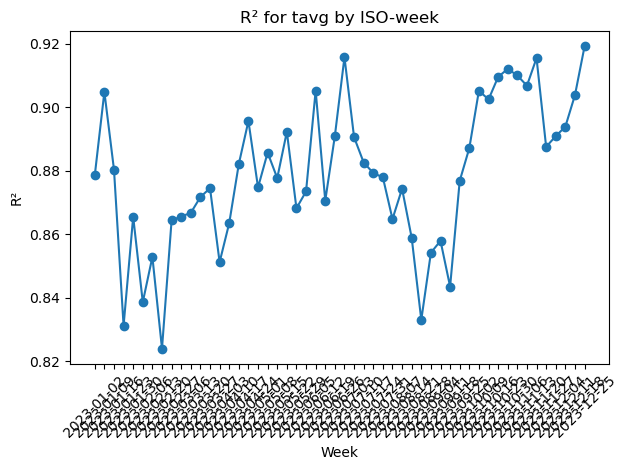

In [24]:
import matplotlib.pyplot as plt          
# ---------------------------------------------------
# 2.  turn the list into a tidy DataFrame
# ---------------------------------------------------
metrics_df = pd.DataFrame(metrics)

# Optional: set index or sort so it’s easier to plot
metrics_df.sort_values(['target','week'], inplace=True)

# ---------------------------------------------------
# 3.  quick plot examples
# ---------------------------------------------------
# plot R² for a single variable over time
fig, ax = plt.subplots()
subset = metrics_df[metrics_df['target']=='tavg']
ax.plot(subset['week'], subset['r2'], marker='o')
ax.set_title('R² for tavg by ISO-week')
ax.set_ylabel('R²')
ax.set_xlabel('Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

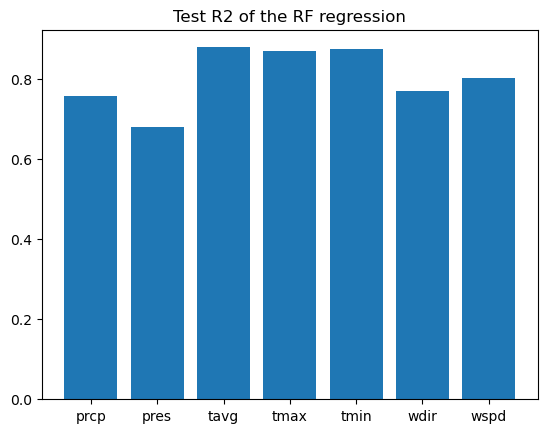

In [30]:
avg_metrics_df = metrics_df.groupby(['target'])[['r2', 'rmse']].mean().reset_index()
plt.bar(avg_metrics_df['target'],avg_metrics_df['r2'] )
plt.title('Test R2 of the RF regression')
plt.show()

In [17]:
data_full.columns

Index(['idx_city', 'week', 'count', 'Latitude', 'Longitude', 'tavg', 'tmin',
       'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'elevation'],
      dtype='object')

In [18]:
df_filled = df_filled[['idx_city', 'week', 'count', 'Latitude', 'Longitude', 'tavg', 'tmin',
       'tmax', 'prcp', 'wdir', 'wspd', 'pres', 'elevation']]

In [19]:
df_final = pd.concat([data_full, df_filled], axis=0)

In [20]:
df_final

,idx_city,week,count,Latitude,Longitude,tavg,tmin,tmax,prcp,wdir,wspd,pres,elevation
0,COLOMBIA_AMAZONAS_LETICIA,2023-01-02,7.0,-4.212921,-69.942596,25.228571,22.985714,29.171429,8.528571,56.000000,4.800000,1010.985714,81.0
1,COLOMBIA_AMAZONAS_LETICIA,2023-01-09,11.0,-4.212921,-69.942596,25.000000,22.328571,29.042857,12.128571,207.857143,4.228571,1010.957143,81.0
2,COLOMBIA_AMAZONAS_LETICIA,2023-01-16,5.0,-4.212921,-69.942596,24.942857,22.257143,28.714286,12.971429,118.857143,3.800000,1010.814286,81.0
3,COLOMBIA_AMAZONAS_LETICIA,2023-01-23,8.0,-4.212921,-69.942596,25.657143,22.771429,30.471429,12.671429,200.857143,4.200000,1009.657143,81.0
4,COLOMBIA_AMAZONAS_LETICIA,2023-01-30,17.0,-4.212921,-69.942596,24.871429,22.328571,29.228571,16.728571,111.714286,4.028571,1010.857143,81.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40611,COLOMBIA_ANTIOQUIA_SOPETRAN,2023-12-25,0.0,6.500958,-75.742498,25.217286,19.917429,30.026571,6.053571,188.807143,7.042857,1014.639714,754.0
40715,COLOMBIA_SANTANDER_GALAN,2023-12-25,0.0,6.637910,-73.287453,22.953143,19.766571,29.541000,12.037714,241.712857,6.039714,1015.252143,936.0
40767,COLOMBIA_SANTANDER_SAN MIGUEL,2023-12-25,0.0,6.575929,-72.645549,20.288857,16.364857,26.603000,12.197571,206.187143,6.603000,1019.074143,1918.0
40819,COLOMBIA_HUILA_TERUEL,2023-12-25,1.0,2.741633,-75.568345,26.190286,22.171143,30.871429,12.598429,123.901429,5.661714,1013.385857,871.0


In [32]:
len(df_final)

40156

In [21]:
df_final.sort_values(by=['week', 'idx_city'], inplace=True)
df_final.reset_index(drop=True, inplace=True)
df_final

,idx_city,week,count,Latitude,Longitude,tavg,tmin,tmax,prcp,wdir,wspd,pres,elevation
0,COLOMBIA_AMAZONAS_LA CHORRERA (CD),2023-01-02,0.0,-1.442015,-72.788936,25.028143,22.172286,29.626286,9.977000,91.128571,5.684857,1011.798571,118.0
1,COLOMBIA_AMAZONAS_LA PEDRERA (CD),2023-01-02,0.0,-1.318317,-69.586380,25.219571,22.558143,29.207857,9.955429,85.745714,5.076429,1011.404143,71.0
2,COLOMBIA_AMAZONAS_LETICIA,2023-01-02,7.0,-4.212921,-69.942596,25.228571,22.985714,29.171429,8.528571,56.000000,4.800000,1010.985714,81.0
3,COLOMBIA_AMAZONAS_PUERTO NARIÑO,2023-01-02,0.0,-3.779943,-70.363977,25.074143,22.337857,29.208000,9.783571,80.864286,5.081714,1011.421857,88.0
4,COLOMBIA_AMAZONAS_TARAPACA (CD),2023-01-02,0.0,-2.891318,-69.741602,25.342143,22.640429,29.432571,9.726143,79.220000,5.065286,1011.303143,65.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
40151,COLOMBIA_VAUPES_PACOA (CD),2023-12-25,0.0,0.022173,-71.004129,25.811143,23.380000,31.339714,9.982286,197.401429,4.775714,1011.904286,150.0
40152,COLOMBIA_VAUPES_TARAIRA,2023-12-25,0.0,-0.563016,-69.634058,25.994429,23.374429,31.233714,11.377714,195.410000,4.420429,1011.576429,124.0
40153,COLOMBIA_VICHADA_CUMARIBO,2023-12-25,0.0,4.447150,-69.797584,25.985429,23.461143,30.954714,8.516286,225.631429,5.299714,1011.687000,159.0
40154,COLOMBIA_VICHADA_LA PRIMAVERA,2023-12-25,0.0,5.551107,-69.616263,27.085286,23.417429,31.802857,3.301714,199.651429,5.948857,1011.355286,91.0


In [22]:
df_final.to_csv('../Data/platinum/dengue_weather_interpolated.csv', index=False)